# Exercise: K-means Clustering

#### In this exercise, we will test our understanding of the core concepts of building optimal K-means clustering models.

## Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Implement a K-means clustering model in sklearn

In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/Live.csv')
df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


### Exercises

#### In this exercise, we want to apply K-means clustering to our data in order to sgement the live posts made by sellers into distinct groups based on their engagement metrics. By clustering similar posts together, we aim to identify patterns or clusters that can help us understand the characteristics of highly engaging posts cersus less engaging ones. This segmentation can provide valuable insights for sellers and marketers to tailor their content strategies more effectively, potentially increasing audience engagement and sales.

#### Exercise 1.1

#### Our dataset contains redundant columns that need to be removed. Identify these columns and drop them from the data

In [3]:
df.shape

(7050, 16)

In [4]:
df.drop(['Column1', 'Column2', 'Column3', 'Column4'], axis=1, inplace=True)

In [5]:
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


In [6]:
df.shape

(7050, 12)

#### Exercise 1.2

#### An essential step in our process is identifying potential label columns, which represent the target variables we could cluster on. In the context of unsupervised laarning, we don't have a designated target variable to predict; however, we can still identify a column that could contain categorical information for which we could cluster our data on.

#### Examine the dataset's attributes and determine which one best represents the categorical information we can cluster on.

In [7]:
df.dtypes

status_id             str
status_type           str
status_published      str
num_reactions       int64
num_comments        int64
num_shares          int64
num_likes           int64
num_loves           int64
num_wows            int64
num_hahas           int64
num_sads            int64
num_angrys          int64
dtype: object

In [8]:
y = df['status_type']

#### Exercise 1.3

#### K-means clustering operates on numerical data and calculates distances between data points based on their numerical attributes. Categorical variables, such as `status_type`, `status_published`, and `status_id` cannot be directly used in distance-based algorithms like K-means.

#### We need the status_type column to use as a categorical column to cluster our data on. However, the rest of the categorical columns will not contribute meaningfully to the clustering process. They contain unique identifiers that do not represent meaningful clusters; keeping them in the analysis would add noise and complexity without enhancing the clustering outcome.

#### Furthermore, the `status_type` column needs to be converted into numerical equivalents to make it compatible with the clustering algorithm.

#### Drop the remaining categorical columns and convert the `status_type`column values to their numerical equivalents.

##### **Hint**: To make this process easier, you can use a library called LabelEncoder, which is a utitlity that is used in machine learning to transform categorical labels into numerical values.

In [9]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the encoder
le = LabelEncoder()

df.drop(['status_id', 'status_published'], axis=1, inplace=True)

In [10]:
df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,529,512,262,432,92,3,1,1,0
1,photo,150,0,0,150,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0
3,photo,111,0,0,111,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0


In [11]:
df['status_type'] = le.fit_transform(df['status_type'])

In [13]:
df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,3,529,512,262,432,92,3,1,1,0
1,1,150,0,0,150,0,0,0,0,0
2,3,227,236,57,204,21,1,1,0,0
3,1,111,0,0,111,0,0,0,0,0
4,1,213,0,0,204,9,0,0,0,0


In [14]:
le.classes_

array(['link', 'photo', 'status', 'video'], dtype=object)

In [15]:
original = le.inverse_transform(df['status_type'])

original

array(['video', 'photo', 'video', ..., 'photo', 'photo', 'photo'],
      shape=(7050,), dtype=object)

In [16]:
df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,3,529,512,262,432,92,3,1,1,0
1,1,150,0,0,150,0,0,0,0,0
2,3,227,236,57,204,21,1,1,0,0
3,1,111,0,0,111,0,0,0,0,0
4,1,213,0,0,204,9,0,0,0,0


In [17]:
df['status_type'].unique()

array([3, 1, 0, 2])

### Exercise 2: Feature Scaling

#### The next step in our process is feature scaling. By scaling the features to a uniform range, we prevent attributes with larger magnitudes from dominating the distance calculations, thus ensuring more balanced clustering results.

#### Perform feature scaling using `MinMaxScaler` on the dataset to ensure that all features contribute equally to the clustering process

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = df.drop('status_type', axis=1)

X_scaled = scaler.fit_transform(X)

### Exercise 3: K-means clustering on a random number of K

#### Now that we have pre-processed and scaled our data, we can now apply K-means clustering to segment the live posts made by sellers into disticnt groups based on their engagement metrics.

#### To start with, let's apply the K-means clustering algorithm to the pre-processed and scaled dataset using a random number of clusters (K). The purpose is to initially explore the data's clustering tendencies and assess the model's performance with different K values. By fitting the K-means model with varying numbers of clusters, we can observe how the data partitions into different groups and evaluate the model's clustering quality.

##### **Exercise 3.1**
##### Apply the K-means model using 6 clusters to start and print the coordinates of the centroids of the clusters that were found by the algorithm

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print('Centroid cluster coordinates: \n', centers)

Centroid cluster coordinates: 
 [[ 8.15944366e+01  2.77829554e+01  5.02586818e+00  7.90598866e+01
   1.85063785e+00  3.92983700e-01  1.61055989e-01  1.01169383e-01
   2.63997165e-02]
 [ 1.55148529e+03  1.68672059e+03  6.94073529e+02  1.18514706e+03
   2.88838235e+02  5.71764706e+01  1.56911765e+01  2.44117647e+00
   2.19117647e+00]
 [ 2.27757005e+03  6.55314010e+01  1.34347826e+01  2.27145894e+03
   3.49758454e+00  2.38164251e+00  2.12560386e-01  1.93236715e-02
  -3.89879101e-16]
 [ 2.52812684e+02  1.05396018e+03  2.08898230e+02  1.82191740e+02
   6.48067847e+01  1.53244838e+00  2.80088496e+00  9.42477876e-01
   5.29498525e-01]
 [ 5.96818182e+02  6.15555682e+03  5.70590909e+02  4.59011364e+02
   1.20227273e+02  4.67045455e+00  8.80681818e+00  2.96590909e+00
   1.13636364e+00]
 [ 9.88827397e+02  1.10594521e+02  3.27945205e+01  9.72983562e+02
   1.20767123e+01  2.85205479e+00  5.91780822e-01  2.10958904e-01
   1.12328767e-01]]


### Exercise 3.2

#### Evaluate the performance of our model by calculating its silhouette_score

In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)

print('Silhouette_score is: ', score)

Silhouette_score is:  0.6728245396168379


### Exercise 4: Finding the best K Value

#### An average silhouette score of 0.7561 suggests a relatively good clustering structure, though not as strong as a score closer to 1

#### Instead of trying to guess the best number of clusters to use, let's use one of the many methods we have at our disposal to find the best K value

##### **Exercise 4.1**
##### Use the Elbow method to find the bese K value for our data

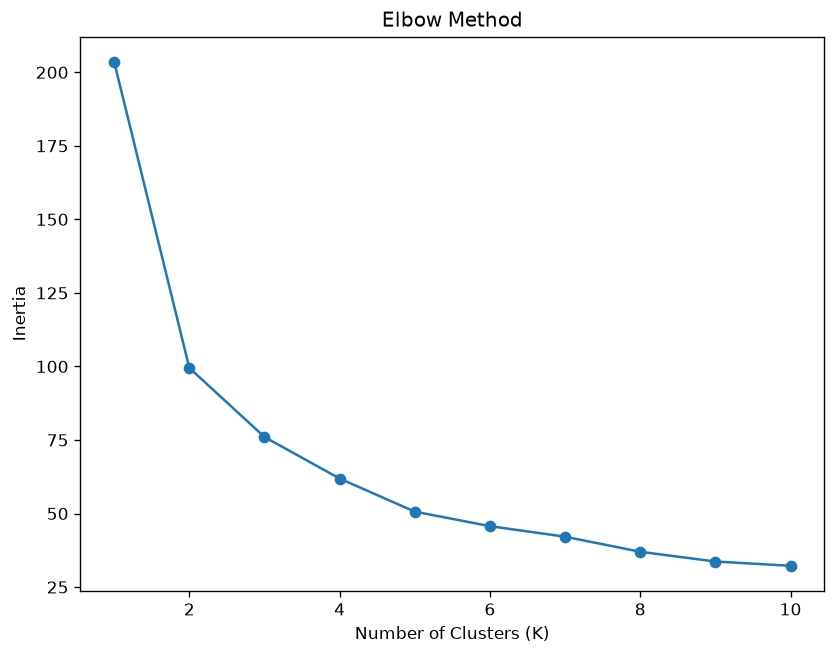

In [28]:
plt.figure(figsize=(8, 6), dpi=120)

inertias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(
    range(1, 11),
    inertias,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### Exercise 4.2

#### We see that there is a kink at K=2. Therefore, K=2 can be considered a good number on which to cluster our data.

#### Based on these results, let's evaluate the performance of our model by calculating the `silhouette_score`. However, this time, let's calculate and plot the silhouette scores for different numbers of clusters, with each point on the plot representing the average silhouette score for a specific number of clusters. This will allow us to analyse the plot and determine the optimal number of clusters for our data based on the highest silhouette score.

#### Calculate and plot the silhouette scores for cluster values from `K=2` to `K=10` clusters.

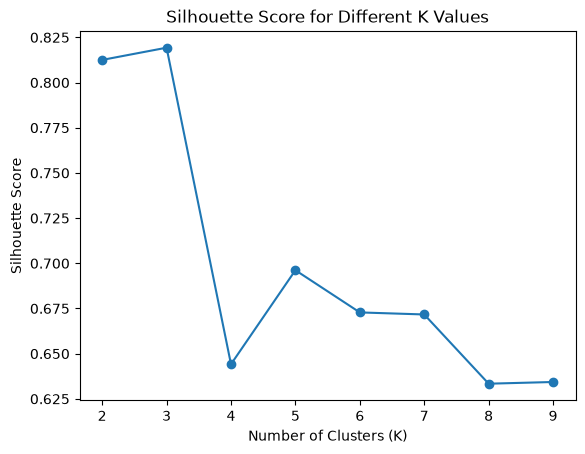

In [27]:
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

k_values = range(2, 10)

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.show()